<a href="https://colab.research.google.com/github/Sasindu99-ai/Statistical-Learning-e22445/blob/main/Assignments%5CAssignment%207%20-%20Kalman%20Filter%5Ce22445_Kalman_filter_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importing libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Q. Analytical Derivation

Consider the filter model
\begin{align*}
x^{-}_k &= A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1}, \\
y^{-}_k &= H_k\,x^{-}_k + z_k,
\end{align*}
where
$$x^{+}_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1}),$$

Answer the followings:

1. Show that
$$x_k^- \sim \mathscr{N}(m_k^-, P_k^-),$$
where
$$m_k^- = A_{k-1}m_{k-1},$$
and
$$
P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T.
$$

2. Show that
$$y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m).$$

3. Show that
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right).$$

4. Show that
$$x^{+}_k\triangleq (x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) \sim \mathscr{N}(m_k, P_k),$$
where the updated mean $m_k$ and updated covariance $P_k$ are given by:
\begin{align*}
K_k &\triangleq P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}, \\
m_k &= m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-), \\
P_k &= (I - K_k H_k) P_k^-.
\end{align*}

5. Find
$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}]$  and
$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k})$.

### 1.

Given

$$
x_k^- = A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1},
$$

where

$$
x_{k-1}^+ \sim \mathcal{N}(m_{k-1}, P_{k-1}), \qquad
w_{k-1} \sim \mathcal{N}(0, \Sigma_p),
$$

and $x_{k-1}^+$ and $w_{k-1}$ are independent.

Since a linear combination of independent Gaussian random variables is also Gaussian,

$$
x_k^- \sim \mathcal{N}(m_k^-, P_k^-).
$$

#### Mean

Using the linearity of expectation,

$$
\begin{aligned}
m_k^-
&= \mathbb{E}[x_k^-] \\
&= \mathbb{E}[A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1}] \\
&= A_{k-1}\mathbb{E}[x_{k-1}^+] + G_{k-1}\mathbb{E}[w_{k-1}] \\
&= A_{k-1}m_{k-1}.
\end{aligned}
$$

Hence,

$$
\boxed{m_k^- = A_{k-1}m_{k-1}.}
$$

#### Covariance

Using the covariance rule for independent random variables,

$$
\begin{aligned}
P_k^-
&= \operatorname{Var}(x_k^-) \\
&= \operatorname{Var}(A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1}) \\
&= A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_pG_{k-1}^T.
\end{aligned}
$$

Hence,

$$
\boxed{
P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_pG_{k-1}^T.
}
$$

### 2.

Given

$$
y_k^- = H_kx_k^- + z_k,
$$

where

$$
x_k^- \sim \mathcal{N}(m_k^-, P_k^-), \qquad
z_k \sim \mathcal{N}(0,\Sigma_m),
$$

and $x_k^-$ and $z_k$ are independent.

Since a linear combination of independent Gaussian random variables is also Gaussian,

$$
y_k^- \sim \mathcal{N}(\mu_y,\Sigma_y).
$$

#### Mean

Using the linearity of expectation,

$$
\begin{aligned}
\mu_y
&= \mathbb{E}[y_k^-] \\
&= \mathbb{E}[H_kx_k^- + z_k] \\
&= H_k\mathbb{E}[x_k^-] + \mathbb{E}[z_k] \\
&= H_km_k^-.
\end{aligned}
$$

#### Covariance

Using the covariance rule for independent random variables,

$$
\begin{aligned}
\Sigma_y
&= \operatorname{Var}(y_k^-) \\
&= \operatorname{Var}(H_kx_k^- + z_k) \\
&= H_kP_k^-H_k^T + \Sigma_m.
\end{aligned}
$$

Hence,

$$
\boxed{
y_k^- \sim
\mathcal{N}\left(
H_km_k^-,
\;
H_kP_k^-H_k^T+\Sigma_m
\right).
}
$$

### 3.

From Q1.1 and Q1.2,

$$
x_k^- \sim \mathcal{N}(m_k^-, P_k^-),
$$

and

$$
y_k^- = H_kx_k^- + z_k,
$$

where

$$
z_k \sim \mathcal{N}(0,\Sigma_m),
$$

and $z_k$ is independent of $x_k^-$.

Since $y_k^-$ is a linear transformation of $x_k^-$ with independent Gaussian noise, the joint vector

$$
\begin{bmatrix}
x_k^-\\
y_k^-
\end{bmatrix}
$$

is Gaussian.

#### Mean

$$
\mathbb{E}
\left[
\begin{bmatrix}
x_k^-\\
y_k^-
\end{bmatrix}
\right]
=
\begin{bmatrix}
m_k^-\\
H_km_k^-
\end{bmatrix}.
$$

#### Covariance

The cross-covariance is

$$
\begin{aligned}
\operatorname{Cov}(x_k^-,y_k^-)
&=\operatorname{Cov}(x_k^-,H_kx_k^-+z_k)\\
&=P_k^-H_k^T,
\end{aligned}
$$

since $z_k$ is independent of $x_k^-$.

Thus,

$$
\operatorname{Cov}(y_k^-,x_k^-)
=
H_kP_k^-.
$$

Therefore,

$$
\boxed{
\begin{bmatrix}
x_k^-\\
y_k^-
\end{bmatrix}
\sim
\mathcal{N}
\left(
\begin{bmatrix}
m_k^-\\
H_km_k^-
\end{bmatrix},
\begin{bmatrix}
P_k^- & P_k^-H_k^T\\
H_kP_k^- & H_kP_k^-H_k^T+\Sigma_m
\end{bmatrix}
\right).
}
$$

### 4.

From Q1.3,

$$
\begin{bmatrix}
x_k^-\\
y_k^-
\end{bmatrix}
$$

is jointly Gaussian. Therefore, the conditional distribution

$$
x_k^+ \triangleq (x_k^- \mid y_k^- = y_k^{\mathrm{obs}})
$$

is also Gaussian.

Using the conditional Gaussian formula,

$$
K_k
=
P_k^-H_k^T
(H_kP_k^-H_k^T+\Sigma_m)^{-1},
$$

the posterior mean is

$$
\boxed{
m_k
=
m_k^+
=
m_k^-
+
K_k
\left(
y_k^{\mathrm{obs}}
-
H_km_k^-
\right).
}
$$

The posterior covariance is

$$
\boxed{
P_k
=
(I-K_kH_k)P_k^-.
}
$$

Hence,

$$
\boxed{
x_k^+
\sim
\mathcal{N}(m_k,P_k).
}
$$

### 5.

Since

$$
x_k^+
=
(x_k^- \mid y_k^- = y_k^{\mathrm{obs}}),
$$

the conditional expectation equals the posterior mean,

$$
\boxed{
\mathbb{E}
[x_k^- \mid y_k^- = y_k^{\mathrm{obs}}]
=
m_k^-
+
K_k
(y_k^{\mathrm{obs}}-H_km_k^-).
}
$$

Similarly, the conditional variance equals the posterior covariance,

$$
\boxed{
\operatorname{Var}
(x_k^- \mid y_k^- = y_k^{\mathrm{obs}})
=
(I-K_kH_k)P_k^-.
}
$$

# Q. 1-D Example

Consider the scalar linear-Gaussian filter model
\begin{aligned}
x^-_k &= a\,x^+_{k-1} + w_{k-1},\qquad w_{k-1}\sim\mathscr N(0,q),\\
y^-_k &= h\,x^-_k + z_k,\qquad\;\;\;\; z_k\sim\mathscr N(0,r),
\end{aligned}
with prior $x_0\sim \mathscr{N}(m_0,P_0)$. Define $Y_{k}=\{y^{\mathrm{obs}}_1,\dots,y^{\mathrm{obs}}_{k}\}$.

Answer the following:

1. Show that
\begin{aligned}
m_k^- &= a\,m_{k-1},\\
P_k^- &= a^2 P_{k-1} + q.
\end{aligned}

2. Show that
\begin{aligned}
m_k &= m_k^- + K_k\,v_k
= m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr),\\
P_k &= (1 - K_k h)\,P_k^-
= \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^- .
\end{aligned}

3. Show that the predictive measurement distribution (before seeing $y_k$):
\begin{align*}
p(y^-_k | Y_{k-1})=\mathscr N\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr).
\end{align*}

4. Show that the posterior-predictive measurement distribution (after filtering on $y_k$):
\begin{align*}
p(y^-_k\mid Y_k)=\mathscr N\bigl(h\,m_k,\; h^2 P_k + r\bigr).
\end{align*}

5. For suitable numerical values for $a,q,h,r$ animate the above to prior distribution and the posterior distribution.

### 1.

The state model is

$$
x_k^- = a\,x_{k-1}^+ + w_{k-1},
$$

where

$$
x_{k-1}^+ \sim \mathcal{N}(m_{k-1},P_{k-1}),
\qquad
w_{k-1}\sim\mathcal{N}(0,q),
$$

and $x_{k-1}^+$ and $w_{k-1}$ are independent.

#### Mean

Using the linearity of expectation,

$$
\begin{aligned}
m_k^-
&=\mathbb{E}[x_k^-] \\
&=\mathbb{E}[ax_{k-1}^+ + w_{k-1}] \\
&=a\mathbb{E}[x_{k-1}^+] + \mathbb{E}[w_{k-1}] \\
&=am_{k-1}.
\end{aligned}
$$

#### Variance

Using the variance rule for independent random variables,

$$
\begin{aligned}
P_k^-
&=\operatorname{Var}(x_k^-) \\
&=\operatorname{Var}(ax_{k-1}^+ + w_{k-1}) \\
&=a^2P_{k-1}+q.
\end{aligned}
$$

Hence,

$$
\boxed{
m_k^- = am_{k-1},
\qquad
P_k^- = a^2P_{k-1}+q.
}
$$

### 2.

The measurement model is

$$
y_k^- = hx_k^- + z_k,
$$

where

$$
z_k\sim\mathcal N(0,r).
$$

The innovation covariance is

$$
S_k=h^2P_k^-+r.
$$

Hence, the Kalman gain is

$$
K_k=\frac{P_k^-h}{S_k}.
$$

The innovation (measurement residual) is

$$
v_k=y_k^{\mathrm{obs}}-hm_k^-.
$$

Therefore, the updated mean is

$$
\boxed{
m_k
=
m_k^-+K_kv_k
=
m_k^-+\frac{P_k^-h}{S_k}
\left(y_k^{\mathrm{obs}}-hm_k^-\right).
}
$$

The updated variance is

$$
\boxed{
P_k
=
(1-K_kh)P_k^-
=
\left(1-\frac{P_k^-h^2}{S_k}\right)P_k^-.
}
$$

### 3.

The measurement model is

$$
y_k^- = hx_k^- + z_k,
$$

where

$$
x_k^- \sim \mathcal N(m_k^-,P_k^-),
\qquad
z_k\sim\mathcal N(0,r),
$$

and $x_k^-$ and $z_k$ are independent.

Since a linear combination of independent Gaussian random variables is Gaussian,

#### Mean

$$
\mathbb E[y_k^-]
=
h\,m_k^-.
$$

#### Variance

$$
\operatorname{Var}(y_k^-)
=
h^2P_k^-+r.
$$

Hence,

$$
\boxed{
p(y_k^-|Y_{k-1})
=
\mathcal N
\left(
hm_k^-,
\;
h^2P_k^-+r
\right).
}
$$

### 4.

After incorporating the observation $y_k^{\mathrm{obs}}$, the posterior state is

$$
x_k^+
\sim
\mathcal N(m_k,P_k).
$$

Using the measurement model

$$
y_k^- = hx_k^+ + z_k,
$$

where

$$
z_k\sim\mathcal N(0,r),
$$

the predictive measurement distribution is Gaussian.

#### Mean

$$
\mathbb E[y_k^-]
=
hm_k.
$$

#### Variance

$$
\operatorname{Var}(y_k^-)
=
h^2P_k+r.
$$

Hence,

$$
\boxed{
p(y_k^-|Y_k)
=
\mathcal N
\left(
hm_k,
\;
h^2P_k+r
\right).
}
$$

### 5.

The following parameters are chosen for the scalar Kalman filter:

$$
a=1.0,\qquad
q=0.2,\qquad
h=1.0,\qquad
r=0.8,
$$

with the initial estimate

$$
m_0=0,\qquad
P_0=1.
$$

At each time step, the prediction step computes the prior distribution

$$
\mathcal N(m_k^-,P_k^-),
$$

which is then updated using the measurement to obtain the posterior distribution

$$
\mathcal N(m_k,P_k).
$$

The animation below illustrates how the posterior distribution becomes more concentrated after incorporating each measurement.

In [ ]:
a = 1.0
q = 0.2
h = 1.0
r = 0.8

m = 0.0
P = 1.0

true_state = 0.0

steps = 20

x = np.linspace(-5, 5, 500)

prior_means = []
prior_vars = []

post_means = []
post_vars = []

measurements = []

# Kalman Filter Simulation
for _ in range(steps):

    # True system
    true_state = a * true_state + np.random.normal(0, np.sqrt(q))

    # Measurement
    y = h * true_state + np.random.normal(0, np.sqrt(r))
    measurements.append(y)

    # Prediction
    m_prior = a * m
    P_prior = a**2 * P + q

    # Kalman Gain
    S = h**2 * P_prior + r
    K = P_prior * h / S

    # Update
    m = m_prior + K * (y - h * m_prior)
    P = (1 - K * h) * P_prior

    prior_means.append(m_prior)
    prior_vars.append(P_prior)

    post_means.append(m)
    post_vars.append(P)

In [ ]:
def gaussian(x, mean, var):
    return (1 / np.sqrt(2 * np.pi * var)) * np.exp(-(x - mean)**2 / (2 * var))


fig, ax = plt.subplots(figsize=(8,5))

prior_line, = ax.plot([], [], lw=2, label="Prior")
post_line, = ax.plot([], [], lw=2, label="Posterior")

title = ax.text(0.5, 1.02, "", transform=ax.transAxes,
                ha="center", fontsize=12)

ax.set_xlim(-5,5)
ax.set_ylim(0,1.2)

ax.set_xlabel("State")
ax.set_ylabel("Probability Density")

ax.legend()


def animate(i):

    prior_pdf = gaussian(x,
                         prior_means[i],
                         prior_vars[i])

    post_pdf = gaussian(x,
                        post_means[i],
                        post_vars[i])

    prior_line.set_data(x, prior_pdf)
    post_line.set_data(x, post_pdf)

    title.set_text(
        f"Step {i+1}    Measurement = {measurements[i]:.2f}"
    )

    return prior_line, post_line, title


ani = FuncAnimation(
    fig,
    animate,
    frames=steps,
    interval=700,
    blit=True
)

plt.close()

HTML(ani.to_jshtml())

# Q. 2D-Position Estimation

## Part A

Consider a two-dimensional constant-velocity dynamical system. The hidden state at time step $k$ is

$$
x_k =
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix},
$$

where $(p_x(k),p_y(k))$ denote the position components and $(v_x(k),v_y(k))$ denote the velocity components.

The measurement consists only of the two position components:

$$
y_k =
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}.
$$

The linear Gaussian state-space filter model is

$$
x^-_k = A x^+_{k-1} + G w_{k-1},
$$

$$
y^-_k = Hx^+_k + z_k,
$$

where

$$
w_{k-1} \sim \mathscr{N}(0,\Sigma_p),
\qquad
z_k \sim \mathscr{N}(0,\Sigma_m).
$$

The process noise sequence $w_k$, measurement noise sequence $z_k$, and the initial state are assumed mutually independent.

Show that:

$$
A =
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix},
$$



$$
H =
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix},
$$

and

$$
G =
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}.
$$

### Part A

For a constant-velocity model with sampling interval $\Delta t$, the position and velocity evolve according to the kinematic equations

$$
\begin{aligned}
p_x(k) &= p_x(k-1) + v_x(k-1)\Delta t + \frac{1}{2}a_x\Delta t^2,\\
p_y(k) &= p_y(k-1) + v_y(k-1)\Delta t + \frac{1}{2}a_y\Delta t^2,\\
v_x(k) &= v_x(k-1) + a_x\Delta t,\\
v_y(k) &= v_y(k-1) + a_y\Delta t,
\end{aligned}
$$

where the random accelerations are represented by the process noise

$$
w_k=
\begin{bmatrix}
a_x\\
a_y
\end{bmatrix}.
$$

The state vector is

$$
x_k=
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix}.
$$

Hence, the state equation can be written as

$$
x_k
=
Ax_{k-1}
+
Gw_{k-1},
$$

where

$$
A=
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix}.
$$

Since only the position components are measured,

$$
y_k=
\begin{bmatrix}
p_x(k)\\
p_y(k)
\end{bmatrix}
+
z_k,
$$

the measurement equation becomes

$$
y_k=Hx_k+z_k,
$$

where

$$

H=
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix}.
$$

The process noise affects the state through acceleration, giving

$$
G=
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}.
$$

Therefore, the required matrices are

$$
A=
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix},
\qquad
H=
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix},
\qquad
G=
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}.
$$

## Part B

Develop a python based method to filter a sequence of noisy GPS obtained position meaurements.

In this part, a Kalman Filter is implemented to estimate the true position and velocity of a moving object from noisy GPS position measurements.

The filter uses the constant-velocity motion model derived in Part (a). At each time step, the filter performs:

1. **Prediction:** Predict the next state and covariance using the system model.
2. **Update:** Correct the prediction using the current GPS measurement.

The estimated positions obtained from the Kalman Filter are then compared with the noisy GPS measurements.

In [ ]:
class KalmanFilter2D:

    def __init__(self, dt, process_var, measurement_var):

        self.dt = dt

        # State transition matrix
        self.A = np.array([
            [1, 0, dt, 0],
            [0, 1, 0, dt],
            [0, 0, 1, 0],
            [0, 0, 0, 1]
        ])

        # Measurement matrix
        self.H = np.array([
            [1, 0, 0, 0],
            [0, 1, 0, 0]
        ])

        # Process noise matrix
        self.G = np.array([
            [0.5 * dt**2, 0],
            [0, 0.5 * dt**2],
            [dt, 0],
            [0, dt]
        ])

        self.Q = process_var * np.eye(2)

        self.R = measurement_var * np.eye(2)

        self.x = np.zeros((4,1))

        self.P = np.eye(4)

    def predict(self):

        self.x = self.A @ self.x

        self.P = self.A @ self.P @ self.A.T + self.G @ self.Q @ self.G.T

    def update(self, z):

        z = np.asarray(z).reshape(2,1)

        y = z - self.H @ self.x

        S = self.H @ self.P @ self.H.T + self.R

        K = self.P @ self.H.T @ np.linalg.inv(S)

        self.x = self.x + K @ y

        I = np.eye(4)

        self.P = (I - K @ self.H) @ self.P

        return self.x

In [ ]:
np.random.seed(10)

dt = 1.0

steps = 60

true_position = np.array([0.0, 0.0])

velocity = np.array([1.2, 0.8])

true_positions = []

gps_measurements = []

for _ in range(steps):

    true_position += velocity * dt

    gps = true_position + np.random.normal(0, 2.5, 2)

    true_positions.append(true_position.copy())

    gps_measurements.append(gps)

true_positions = np.array(true_positions)

gps_measurements = np.array(gps_measurements)

In [ ]:
kf = KalmanFilter2D(
    dt=1.0,
    process_var=0.2,
    measurement_var=6.25     # GPS std = 2.5 m
)

filtered_positions = []

for measurement in gps_measurements:

    kf.predict()

    state = kf.update(measurement)

    filtered_positions.append(state[:2].flatten())

filtered_positions = np.array(filtered_positions)

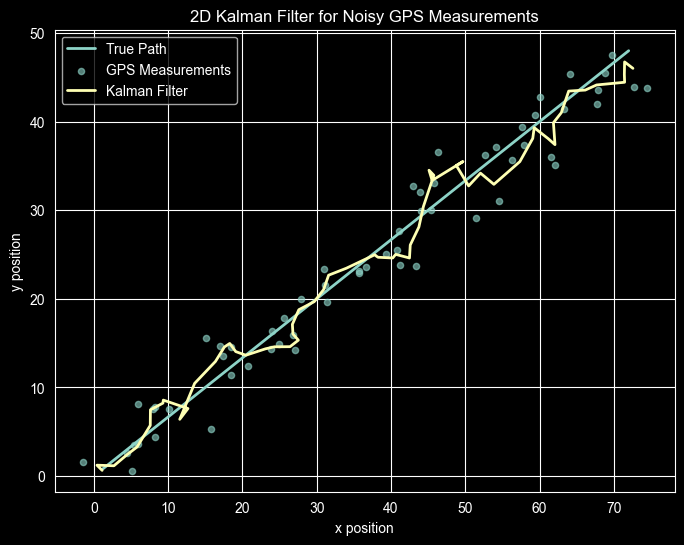

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(
    true_positions[:,0],
    true_positions[:,1],
    label="True Path",
    linewidth=2
)

plt.scatter(
    gps_measurements[:,0],
    gps_measurements[:,1],
    s=20,
    alpha=0.6,
    label="GPS Measurements"
)

plt.plot(
    filtered_positions[:,0],
    filtered_positions[:,1],
    label="Kalman Filter",
    linewidth=2
)

plt.xlabel("x position")

plt.ylabel("y position")

plt.title("2D Kalman Filter for Noisy GPS Measurements")

plt.legend()

plt.grid(True)

plt.show()